In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# First look
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

In [4]:
# Missing values check
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df['TotalCharges'].dtype

<StringDtype(storage='python', na_value=nan)>

In [6]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became NaN after conversion
df['TotalCharges'].isnull().sum()

np.int64(11)

In [7]:
df = df.dropna(subset=['TotalCharges'])
print("New shape after cleaning:", df.shape)

New shape after cleaning: (7032, 21)


In [8]:
# customerID drop pannu - analysis-ku use aagathu
df = df.drop('customerID', axis=1)

# Churn column oda Yes/No count
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

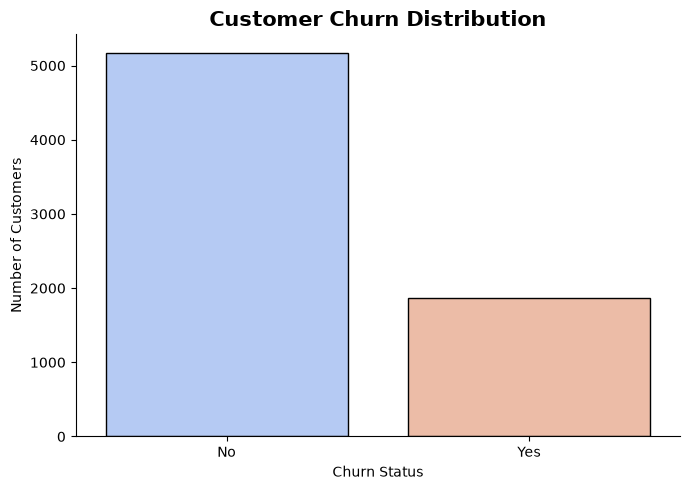

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Churn', hue='Churn', palette='coolwarm', legend=False, edgecolor='black')
plt.title('Customer Churn Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
sns.despine()
plt.tight_layout()
plt.show()

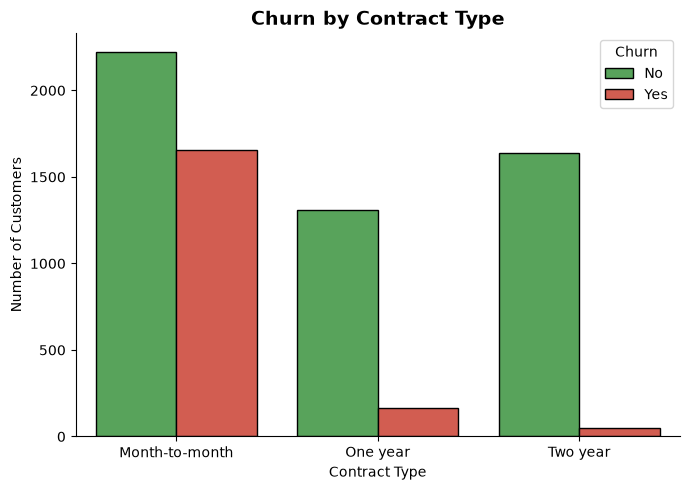

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#4CAF50', '#E74C3C'], edgecolor='black')
plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
sns.despine()
plt.tight_layout()
plt.show()

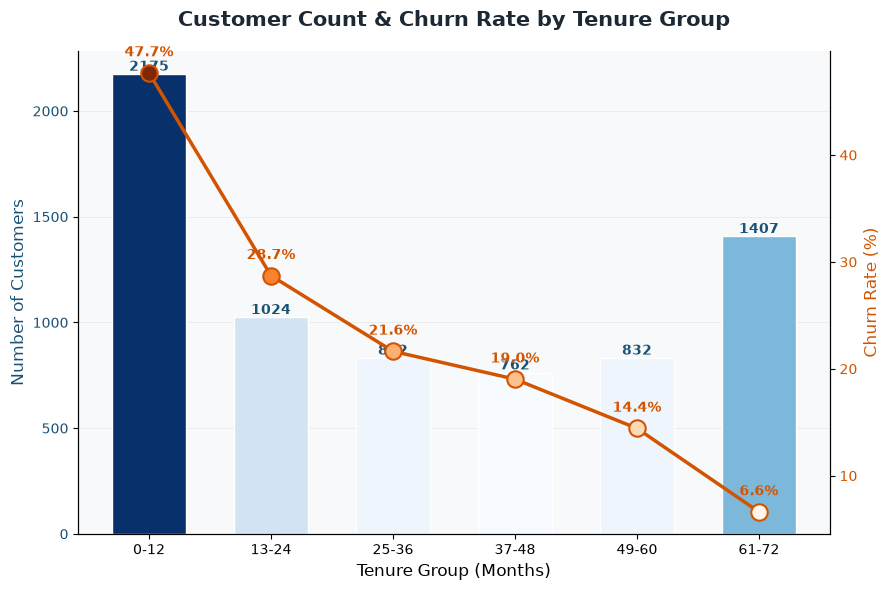

In [18]:
import matplotlib.colors as mcolors

# ---------- Tenure Groups ----------
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

grouped = df.groupby('tenure_group', observed=True).agg(
    total_customers=('Churn', 'count'),
    churned=('Churn', lambda x: (x == 'Yes').sum())
).reset_index()

grouped['churn_rate'] = (grouped['churned'] / grouped['total_customers']) * 100

# ---------- Gradient Setup ----------
norm = mcolors.Normalize(vmin=grouped['total_customers'].min(), vmax=grouped['total_customers'].max())
bar_cmap = plt.colormaps['Blues']
bar_colors = [bar_cmap(norm(val)) for val in grouped['total_customers']]

line_cmap = plt.colormaps['Oranges']
line_norm = mcolors.Normalize(vmin=grouped['churn_rate'].min(), vmax=grouped['churn_rate'].max())

# ---------- Combo Chart ----------
fig, ax1 = plt.subplots(figsize=(9,6))
fig.patch.set_facecolor('white')

bars = ax1.bar(grouped['tenure_group'], grouped['total_customers'],
                color=bar_colors, edgecolor='white', linewidth=1, width=0.6)
ax1.set_xlabel('Tenure Group (Months)', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12, color='#1a5276')
ax1.tick_params(axis='y', labelcolor='#1a5276')
ax1.grid(axis='y', color='#E5E7E9', linewidth=0.7, alpha=0.7)
ax1.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}', (bar.get_x() + bar.get_width()/2, height),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1a5276')

ax2 = ax1.twinx()
ax2.plot(grouped['tenure_group'], grouped['churn_rate'],
         color='#D35400', linewidth=2.5, zorder=1)

for i, val in enumerate(grouped['churn_rate']):
    ax2.scatter(i, val, color=line_cmap(line_norm(val)), s=140,
                edgecolor='#D35400', linewidth=1.5, zorder=2)
    ax2.annotate(f'{val:.1f}%', (i, val), textcoords="offset points",
                 xytext=(0,12), ha='center', fontsize=10, fontweight='bold', color='#D35400')

ax2.set_ylabel('Churn Rate (%)', fontsize=12, color='#D35400')
ax2.tick_params(axis='y', labelcolor='#D35400')
ax2.grid(False)

for spine in ['top']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.title('Customer Count & Churn Rate by Tenure Group', fontsize=15, fontweight='bold',
          color='#1C2833', pad=18)
fig.tight_layout()
plt.show()

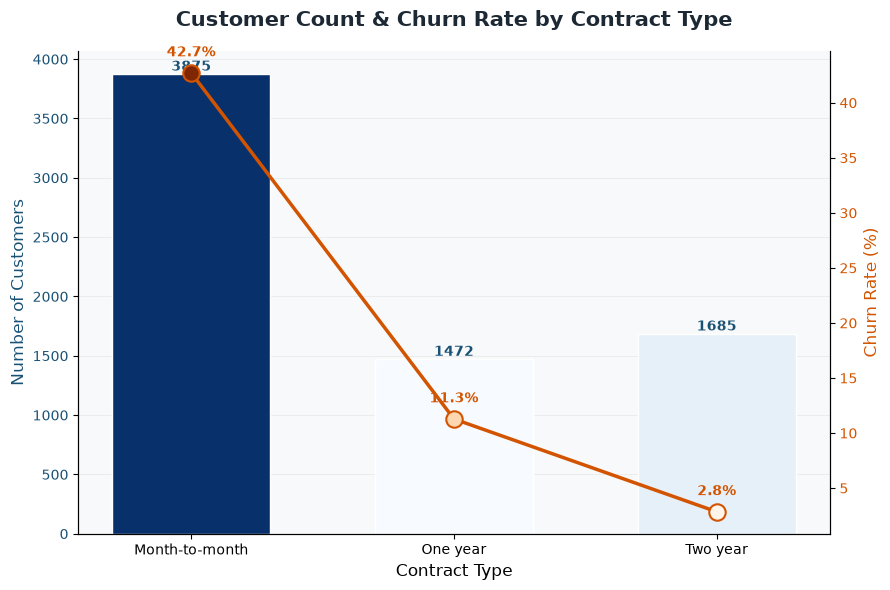

In [21]:
import matplotlib.colors as mcolors

# ---------- Group by Contract ----------
grouped_contract = df.groupby('Contract', observed=True).agg(
    total_customers=('Churn', 'count'),
    churned=('Churn', lambda x: (x == 'Yes').sum())
).reset_index()

grouped_contract['churn_rate'] = (grouped_contract['churned'] / grouped_contract['total_customers']) * 100

# ---------- Gradient Setup ----------
norm = mcolors.Normalize(vmin=grouped_contract['total_customers'].min(), vmax=grouped_contract['total_customers'].max())
bar_cmap = plt.colormaps['Blues']
bar_colors = [bar_cmap(norm(val)) for val in grouped_contract['total_customers']]

line_cmap = plt.colormaps['Oranges']
line_norm = mcolors.Normalize(vmin=grouped_contract['churn_rate'].min(), vmax=grouped_contract['churn_rate'].max())

# ---------- Combo Chart ----------
fig, ax1 = plt.subplots(figsize=(9,6))
fig.patch.set_facecolor('white')

bars = ax1.bar(grouped_contract['Contract'], grouped_contract['total_customers'],
                color=bar_colors, edgecolor='white', linewidth=1, width=0.6)
ax1.set_xlabel('Contract Type', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12, color='#1a5276')
ax1.tick_params(axis='y', labelcolor='#1a5276')
ax1.grid(axis='y', color='#E5E7E9', linewidth=0.7, alpha=0.7)
ax1.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{int(height)}', (bar.get_x() + bar.get_width()/2, height),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1a5276')

ax2 = ax1.twinx()
ax2.plot(grouped_contract['Contract'], grouped_contract['churn_rate'],
         color='#D35400', linewidth=2.5, zorder=1)

for i, val in enumerate(grouped_contract['churn_rate']):
    ax2.scatter(i, val, color=line_cmap(line_norm(val)), s=140,
                edgecolor='#D35400', linewidth=1.5, zorder=2)
    ax2.annotate(f'{val:.1f}%', (i, val), textcoords="offset points",
                 xytext=(0,12), ha='center', fontsize=10, fontweight='bold', color='#D35400')

ax2.set_ylabel('Churn Rate (%)', fontsize=12, color='#D35400')
ax2.tick_params(axis='y', labelcolor='#D35400')
ax2.grid(False)

for spine in ['top']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.title('Customer Count & Churn Rate by Contract Type', fontsize=15, fontweight='bold',
          color='#1C2833', pad=18)
fig.tight_layout()
plt.show()